In [6]:
#Load necessary libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Flatten,Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
from tensorflow.keras.models import Sequential,Model
import numpy as np
import  matplotlib.pyplot as plt

In [7]:
#Load the dataset
(xtrain,ytrain),(xtest,ytest)=mnist.load_data()

In [8]:
#Preprocess the dataset
xtrain = np.expand_dims(xtrain, -1)
xtest = np.expand_dims(xtest, -1)
xtrain = np.repeat(xtrain, 3, axis=-1)
xtest = np.repeat(xtest, 3, axis=-1)
xtrain = resize(xtrain, (32,32))
xtest = resize(xtest, (32,32))
xtrain, xtest = xtrain / 255.0, xtest / 255.0
ytrain, ytest = to_categorical(ytrain), to_categorical(ytest)

In [9]:
#Build the feature extractor model using VGG19
vgg=VGG19(weights='imagenet',input_shape=(32,32,3),include_top=False)
for layers in vgg.layers:
    layers.trainable=False
layer_2 = Flatten()(vgg.output)
layer_3 = Dense(256,activation='relu')(layer_2)
output = Dense(10,activation='sigmoid')(layer_3)
model = Model(inputs=vgg.input,outputs=output)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(xtrain,ytrain,batch_size=32,epochs=5,validation_data=(xtest,ytest))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 74ms/step - accuracy: 0.9045 - loss: 0.0647 - val_accuracy: 0.9537 - val_loss: 0.0315
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 131s 70ms/step - accuracy: 0.9582 - loss: 0.0278 - val_accuracy: 0.9664 - val_loss: 0.0226
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 132s 71ms/step - accuracy: 0.9664 - loss: 0.0221 - val_accuracy: 0.9698 - val_loss: 0.0200
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 135s 72ms/step - accuracy: 0.9700 - loss: 0.0193 - val_accuracy: 0.9724 - val_loss: 0.0187
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 131s 70ms/step - accuracy: 0.9724 - loss: 0.0175 - val_accuracy: 0.9694 - val_loss: 0.0196


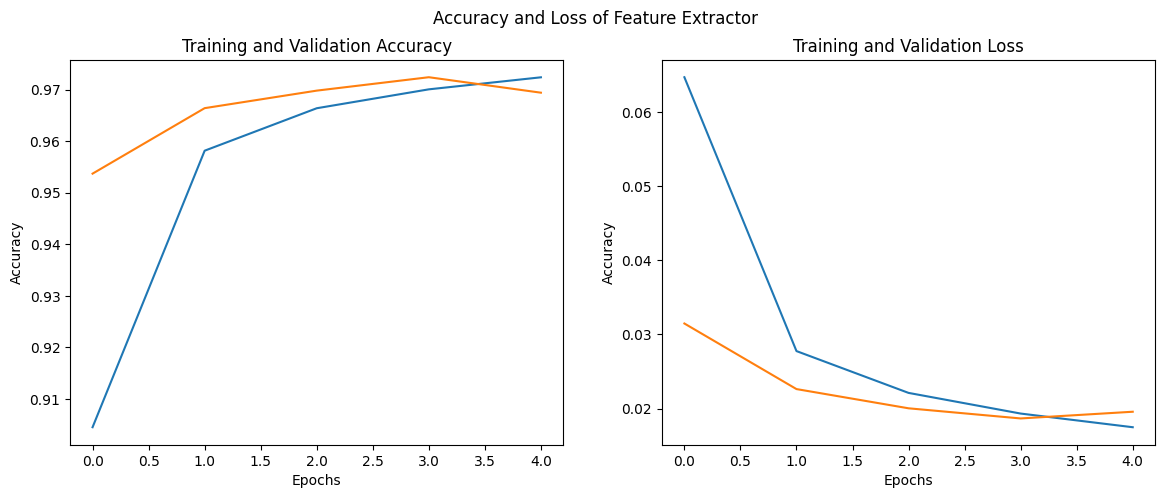

In [12]:
#Display the validation and test accuracy of feature extractor model using vgg19
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.plot(history.history['accuracy'],label='Training Accuracy')
ax1.plot(history.history['val_accuracy'],label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax2.plot(history.history['loss'],label='Training Loss')
ax2.plot(history.history['val_loss'],label='Validation Score')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
fig.suptitle('Accuracy and Loss of Feature Extractor')
plt.show()

In [ ]:
#Build the fine tune model using VGG19
vgg=VGG19(weights='imagenet',input_shape=(32,32,3),include_top=False)
for layers in vgg.layers:
    layers.trainable=True
layer_2 = Flatten()(vgg.output)
layer_3 = Dense(256,activation='relu')(layer_2)
output = Dense(10,activation='sigmoid')(layer_3)
model = Model(inputs=vgg.input,outputs=output)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(xtrain,ytrain,batch_size=32,epochs=5,validation_data=(xtest,ytest))


Epoch 1/5
  25/1875 ━━━━━━━━━━━━━━━━━━━━ 8:47 285ms/step - accuracy: 0.1006 - loss: 0.4066

In [ ]:
#Display the validation and test accuracy of fine tune model using vgg19
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))
ax1.plot(history.history['accuracy'],label='Training Accuracy')
ax1.plot(history.history['val_accuracy'],label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1_set_xlabel('Epochs')
ax1_set_ylabel('Accuracy')
ax2.plot(history.histoty['loss'],label='Training Loss')
ax2.plot(history.history['val_loss'],label='Validation Score')
ax2.set_title('Training and Validation Loss')
ax2_set_xlabel('Epochs')
ax2_set_ylabel('Accuracy')
fig.suptitle('Accuracy and Loss of Fine Tune Model')
plt.show()